# Develop Raman scaling

In [4]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas
from scipy.interpolate import interp1d

from ocpy.pace import io as pace_io
from ocpy.utils import plotting
from ocpy.hydrolight import loisel23
from ocpy.utils import coords as ocpy_coords
from ocpy.water import scattering

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Locals

# Load up L23

In [5]:
l23_10 = loisel23.load_ds(1,0)
l23_20 = loisel23.load_ds(2,0)
l23_40 = loisel23.load_ds(4,0)
#
wave = l23_10.Lambda

In [6]:
def grab_data(idx):
    return l23_10.Rrs[idx], l23_20.Rrs[idx], l23_40.Rrs[idx]

# Plot an example

In [7]:
idx = 170
Rrs_10, Rrs_20, Rrs_40 = grab_data(idx)

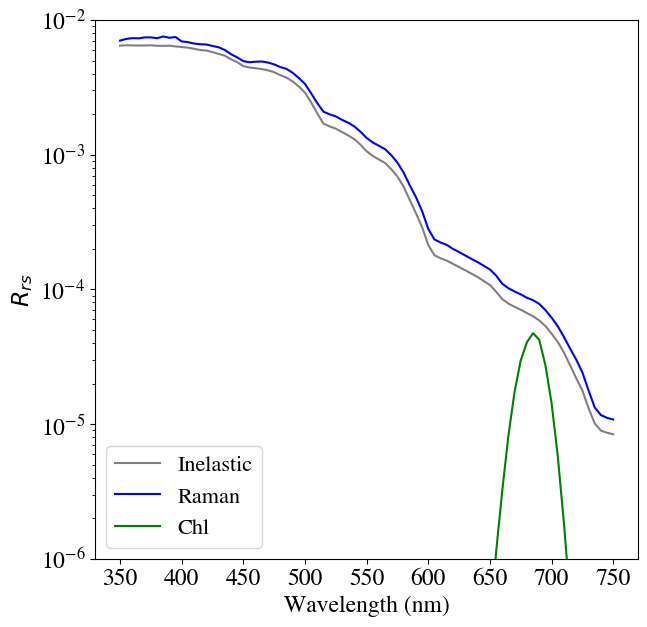

In [8]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(wave, Rrs_10, label='Inelastic', color='gray')
ax.plot(wave, Rrs_20, label='Raman', color='blue')
ax.plot(wave, Rrs_40-Rrs_20, label='Chl', color='green')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$')
ax.set_yscale('log')
ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower left', fontsize=16.)
plt.show()

## Relative

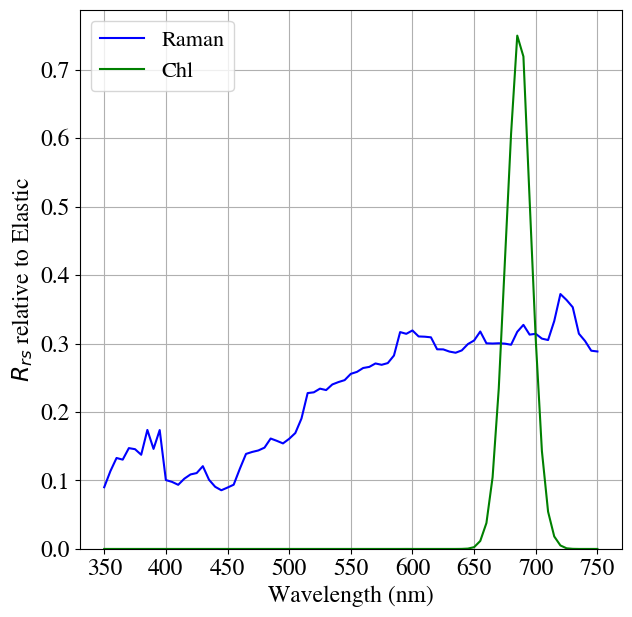

In [9]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(wave, (Rrs_20-Rrs_10)/Rrs_10, label='Raman', color='blue')
ax.plot(wave, (Rrs_40-Rrs_20)/Rrs_10, label='Chl', color='green')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$ relative to Elastic')
#ax.set_yscale('log')
ax.grid()
ax.set_ylim(0., None)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='upper left', fontsize=16.)
plt.show()

# Gordon 1999 writes that "two-flow models of radiative transfer show that the ratio of the Raman to the elastic contributions to $E_u$ should be roughly proportional to:

# $\frac{a(\lambda)}{a(\lambda) + a(\lambda_e)}$

## where $\lambda_e$ is the wavelength of light that would excite Raman emission at wavelength $\lambda$

In [10]:
def calc_Raman_to_Elastic(wv, a, awave):
    # Generate interpolator
    f_a = interp1d(awave, a)
    #
    wv_e = calc_le(wv)
    a_i = f_a(wv)
    a_e = f_a(wv_e)
    # Finish
    return a_i / (a_i + a_e)

## Furthermore, Mobley reports that:

# $\lambda = \frac{10^7}{\frac{10^7}{\lambda_e} - 3400}$

## with $\lambda$ in nm

# Inverting the last equation

# $\lambda_e = \frac{10^7}{\frac{10^7}{\lambda} + 3400}$

In [11]:
def calc_le(l):
    return 1e7 / (1e7/l + 3400)

In [12]:
calc_le(583.)

486.55505666739

In [13]:
calc_le(400.)

352.11267605633805

In [18]:
calc_le(460.)

397.7862331373227

# Let's approximate

In [20]:
l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10l23_10

<xarray.Dataset> Size: 18MB
Dimensions:  (Lambda: 81, IOP_Scenario: 3320)
Coordinates:
  * Lambda   (Lambda) float32 324B 350.0 355.0 360.0 365.0 ... 740.0 745.0 750.0
Dimensions without coordinates: IOP_Scenario
Data variables: (12/17)
    Rrs      (IOP_Scenario, Lambda) float32 1MB 0.01084 0.01084 ... 2.8e-05
    Ed_0+    (IOP_Scenario, Lambda) float32 1MB 0.7753 0.7314 ... 1.237 1.222
    Lw       (IOP_Scenario, Lambda) float32 1MB 0.0084 0.007927 ... 3.421e-05
    Lu_0+    (IOP_Scenario, Lambda) float32 1MB 0.04003 0.03817 ... 0.0624
    a        (IOP_Scenario, Lambda) float32 1MB 0.03096 0.02925 ... 2.83 2.85
    anw      (IOP_Scenario, Lambda) float32 1MB 0.02386 0.02245 ... 0.0004
    ...       ...
    bph      (IOP_Scenario, Lambda) float32 1MB 0.04521 0.04454 ... 0.1008
    bd       (IOP_Scenario, Lambda) float32 1MB 0.03323 0.03239 ... 0.03513
    bb       (IOP_Scenario, Lambda) float32 1MB 0.006968 0.006587 ... 0.001876
    bbnw     (IOP_Scenario, Lambda) float32 1MB 0.00105 0.001028 ... 0.001641
    bbph     (IOP_Scenario, Lambda) float32 1MB 0.0004521 0.0004454 ... 0.001008
    bbd      (IOP_Scenario, Lambda) float32 1MB 0.0005982 0.000583 ... 0.0006324

In [21]:
a = l23_10.a[idx]
aw = l23_10.a[idx] - l23_10.anw[idx]
ag = l23_10.ag[idx]

In [31]:
wvmin, wvmax = 400, 700
wv = np.linspace(wvmin, wvmax, 300)
R_E = calc_Raman_to_Elastic(wv, aw+ag, wave)

## Plot

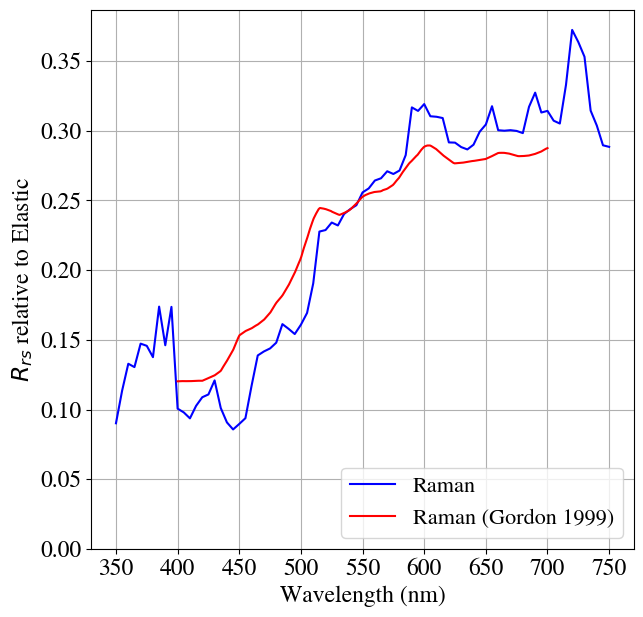

In [57]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(wave, (Rrs_20-Rrs_10)/Rrs_10, label='Raman', color='blue')
ax.plot(wv, R_E*0.318, label='Raman (Gordon 1999)', color='red')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$ relative to Elastic')
ax.grid()
ax.set_ylim(0., None)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower right', fontsize=16.)
plt.show()

# Let's derive the "best" scaling

## Brute force

In [37]:
isub_wv = (wave >= wvmin) & (wave <= wvmax)
sub_wv = wave[isub_wv].data
sub_wv

array([400., 405., 410., 415., 420., 425., 430., 435., 440., 445., 450.,
       455., 460., 465., 470., 475., 480., 485., 490., 495., 500., 505.,
       510., 515., 520., 525., 530., 535., 540., 545., 550., 555., 560.,
       565., 570., 575., 580., 585., 590., 595., 600., 605., 610., 615.,
       620., 625., 630., 635., 640., 645., 650., 655., 660., 665., 670.,
       675., 680., 685., 690., 695., 700.], dtype=float32)

In [41]:
unit_gordon = calc_Raman_to_Elastic(sub_wv, aw+ag, wave)
scales = np.linspace(0.1, 10., 1000)
#all_gordon = np.outer(scales, unit_gordon)
all_gordon = np.outer(unit_gordon, scales)
all_gordon.shape

(61, 1000)

In [39]:
true_Raman = (Rrs_20-Rrs_10)/Rrs_10
true_Raman = true_Raman[isub_wv]
true_Raman.shape

(61,)

In [45]:
diff = all_gordon - np.outer(true_Raman, np.ones(scales.size))
chisq = np.sum(diff**2, axis=0)
chisq.shape

(1000,)

In [51]:
imin = np.argmin(chisq)
best_scale = scales[imin]
best_scale

np.float64(0.31801801801801804)

## Plot

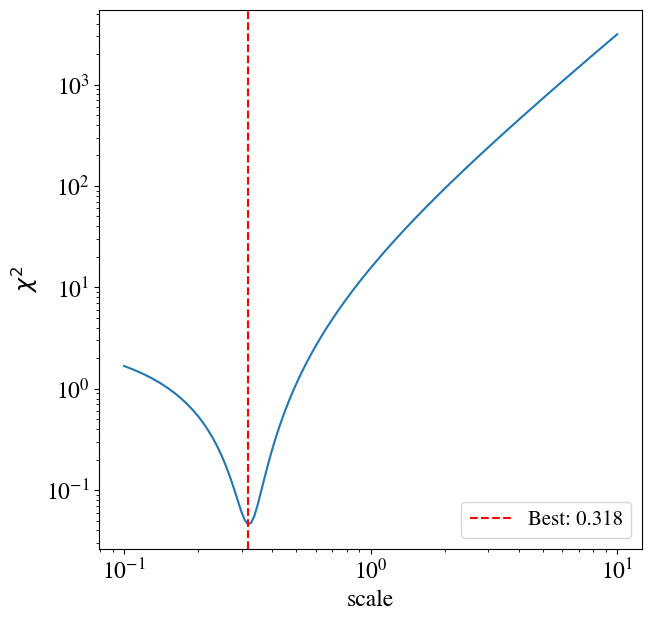

In [56]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
ax.plot(scales, chisq)
#
ax.set_xlabel('scale')
ax.set_ylabel(r'$\chi^2$')
ax.set_xscale('log')
ax.set_yscale('log')
#
ax.axvline(best_scale,color='r',ls='--', label=f'Best: {best_scale:0.3f}')
#
plotting.set_fontsize(ax, 17)
ax.legend(fontsize=15.)
#
plt.show()